Overall Question: During major oil market shocks, which moves first — intraday price volatility or trading volume — and does this lead-lag relationship differ between geopolitical conflicts and economic crises?

Overall Conclusion: Geopolitical oil shocks do not produce a consistent lead-lag relationship between volume and volatility. The pattern varies by conflict type and is universally weak, suggesting oil markets react to geopolitical shocks contemporaneously — both metrics spike together — rather than through a sequential signalling process. This challenges the assumption that volume acts as a leading confirming indicator in crisis periods, which is a counterintuitive and genuinely interesting finding.

In [1]:
import pandas as pd
df = pd.read_csv('rude oil 2.csv')
print(df.head())
print(df.dtypes)
print(df.shape)
print(df.isnull().sum())


         Date       Open       High        Low      Close  Volume
0  2000-08-23  31.950001  32.799999  31.950001  32.049999   79385
1  2000-08-24  31.900000  32.240002  31.400000  31.629999   72978
2  2000-08-25  31.700001  32.099998  31.320000  32.049999   44601
3  2000-08-28  32.040001  32.919998  31.860001  32.869999   46770
4  2000-08-29  32.820000  33.029999  32.560001  32.720001   49131
Date       object
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object
(6407, 6)
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [2]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)
print(df.index.min())
print(df.index.max())
print(df.index.year.unique())


2000-08-23 00:00:00
2026-03-02 00:00:00
Index([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023,
       2024, 2025, 2026],
      dtype='int32', name='Date')


In [3]:
df

,Open,High,Low,Close,Volume
Date,,,,,
2000-08-23,31.950001,32.799999,31.950001,32.049999,79385
2000-08-24,31.900000,32.240002,31.400000,31.629999,72978
2000-08-25,31.700001,32.099998,31.320000,32.049999,44601
2000-08-28,32.040001,32.919998,31.860001,32.869999,46770
2000-08-29,32.820000,33.029999,32.560001,32.720001,49131
...,...,...,...,...,...
2026-02-24,66.309998,67.150002,65.550003,65.629997,312124
2026-02-25,66.070000,66.599998,65.120003,65.419998,306780
2026-02-26,65.650002,66.709999,63.599998,65.209999,498542


In [4]:
df['Volatility'] = df['High'] - df['Low']
print(df[['High', 'Low', 'Volatility']].head(10))

                 High        Low  Volatility
Date                                        
2000-08-23  32.799999  31.950001    0.849998
2000-08-24  32.240002  31.400000    0.840002
2000-08-25  32.099998  31.320000    0.779999
2000-08-28  32.919998  31.860001    1.059998
2000-08-29  33.029999  32.560001    0.469997
2000-08-30  33.400002  32.099998    1.300003
2000-08-31  33.700001  32.970001    0.730000
2000-09-01  33.450001  32.750000    0.700001
2000-09-05  33.990002  33.419998    0.570004
2000-09-06  34.950001  33.830002    1.119999


## Step 2 — Normalising Volume and Volatility

Raw volume and volatility numbers are not directly comparable across different time periods — average trading volumes in 2003 differ significantly from 2022. Normalisation expresses each day's value as a ratio relative to a baseline average, making all event windows comparable regardless of era.

A 30-day window was chosen as the baseline, approximating one month of recent market activity. This is long enough to represent stable pre-event conditions without capturing the tail of prior shocks, and short enough to remain sensitive to regime changes. The 30-day convention is standard in financial volatility analysis.

However, a rolling baseline has a key limitation for long conflicts — once the event exceeds 30 days, conflict-period data begins contaminating the baseline itself, understating how abnormal later days actually are. To address this, each conflict window in the analysis uses a fixed pre-event baseline calculated from the 30 days immediately before that conflict began. This baseline remains frozen 
for the entire conflict duration, ensuring the measuring stick is never corrupted 
by the anomaly it is measuring.

The rolling columns below are retained for general dataset visualisation only.
A limitation worth acknowledging is that the 30-day window size is assumed 
rather than optimised — a sensitivity analysis across multiple window sizes 
would strengthen the robustness of these conclusions.


In [5]:
#Rolling baseline - used for general visulisation only
df['Volume_MA30'] = df['Volume'].rolling(window=30).mean()
df['Volatility_MA30'] = df['Volatility'].rolling(window=30).mean()

df['Volume_Norm_Rolling'] = df['Volume'] / df['Volume_MA30']
df['Volatility_Norm_Rolling'] = df['Volatility'] / df['Volatility_MA30']

# Define conflict windows and their pre-event baseline periods
conflicts = {
    'Post 9/11': {
        'baseline_start': '2001-07-12',
        'baseline_end': '2001-09-10',
        'event_start': '2001-09-11',
        'event_end': '2002-03-11'
    },
    'Iraq War': {
        'baseline_start': '2003-01-01',
        'baseline_end': '2003-03-19',
        'event_start': '2003-03-20',
        'event_end': '2003-12-31'
    },
    'Russia-Ukraine': {
        'baseline_start': '2021-12-25',
        'baseline_end': '2022-02-23',
        'event_start': '2022-02-24',
        'event_end': '2023-06-30'
    },
    'Iran-US Tension': {
        'baseline_start': '2026-01-20',
        'baseline_end': '2026-02-26',
        'event_start': '2026-02-27',
        'event_end': '2026-03-10'
    }
}

# For each conflict, fix pre-event baseline and normalise
for name, dates in conflicts.items():
    baseline = df[dates['baseline_start']:dates['baseline_end']]

    baseline_vol_mean = baseline['Volume'].mean()
    baseline_volatility_mean = baseline['Volatility'].mean()

    event = df[dates['event_start']:dates['event_end']]

    df.loc[dates['event_start']:dates['event_end'], f'{name}_Volume_Norm'] = (
        event['Volume'] / baseline_vol_mean
    )
    df.loc[dates['event_start']:dates['event_end'], f'{name}_Volatility_Norm'] = (
        event['Volatility'] / baseline_volatility_mean
    )

print("Conflicts defined and normalised successfully")
print(df.filter(like='Norm').head(50))

Conflicts defined and normalised successfully
            Volume_Norm_Rolling  Volatility_Norm_Rolling  \
Date                                                       
2000-08-23                  NaN                      NaN   
2000-08-24                  NaN                      NaN   
2000-08-25                  NaN                      NaN   
2000-08-28                  NaN                      NaN   
2000-08-29                  NaN                      NaN   
2000-08-30                  NaN                      NaN   
2000-08-31                  NaN                      NaN   
2000-09-01                  NaN                      NaN   
2000-09-05                  NaN                      NaN   
2000-09-06                  NaN                      NaN   
2000-09-07                  NaN                      NaN   
2000-09-08                  NaN                      NaN   
2000-09-11                  NaN                      NaN   
2000-09-12                  NaN                      N

The 30-day window size is assumed rather than optimised — a sensitivity analysis 
across multiple window sizes would strengthen the robustness of these conclusions.

### Conflict Selection
Four geopolitical conflicts were selected, all sharing the same transmission 
mechanism — supply disruption through physical obstruction or destruction of 
oil infrastructure and trade routes rather than demand collapse:

- Post 9/11 (September 2001 — March 2002)
- Iraq War (March 2003 — December 2003)
- Russia-Ukraine War (February 2022 — June 2023)
- Iran-US Tension (February 2026 — present)

### Iran-US Tension Caveat
The Iran-US conflict window covers only 11 days of data as of the time of 
writing, which is insufficient for robust lead-lag conclusions. It is included 
as a preliminary signal and treated separately from the three historical 
conflicts when drawing generalisable conclusions.

In [6]:
# test for code
print(df.loc['2003-03-20':'2003-04-10', ['Iraq War_Volume_Norm', 'Iraq War_Volatility_Norm']])

            Iraq War_Volume_Norm  Iraq War_Volatility_Norm
Date                                                      
2003-03-20              1.541455                  2.074988
2003-03-21              1.116921                  1.117302
2003-03-24              0.800797                  1.037493
2003-03-25              1.020053                  1.596145
2003-03-26              0.826542                  0.710285
2003-03-27              0.852901                  0.917783
2003-03-28              0.693347                  0.837977
2003-03-31              0.521391                  0.901823
2003-04-01              0.684207                  1.556242
2003-04-02              0.748256                  0.654419
2003-04-03              0.707885                  0.798072
2003-04-04              0.632091                  0.933745
2003-04-07              0.722590                  0.798072
2003-04-08              0.670027                  0.558650
2003-04-09              0.771532                  1.1412

In [7]:
results = {}

for name in conflicts.keys():
    event = df.loc[conflicts[name]['event_start']:conflicts[name]['event_end'],
                   [f'{name}_Volume_Norm', f'{name}_Volatility_Norm']].copy()
    
    # Create lagged columns
    event['Volume_Lag1'] = event[f'{name}_Volume_Norm'].shift(1)
    event['Volatility_Lag1'] = event[f'{name}_Volatility_Norm'].shift(1)
    
    # Drop NaN row created by shift
    event = event.dropna()
    
    # Calculate correlations
    vol_leads = event['Volume_Lag1'].corr(event[f'{name}_Volatility_Norm'])
    volatility_leads = event['Volatility_Lag1'].corr(event[f'{name}_Volume_Norm'])
    
    results[name] = {
        'Volume leads Volatility': round(vol_leads, 4),
        'Volatility leads Volume': round(volatility_leads, 4)
    }

for name, corrs in results.items():
    print(f"\n{name}")
    print(f"  Volume leads Volatility:    {corrs['Volume leads Volatility']}")
    print(f"  Volatility leads Volume:    {corrs['Volatility leads Volume']}")



Post 9/11
  Volume leads Volatility:    0.1245
  Volatility leads Volume:    -0.1679

Iraq War
  Volume leads Volatility:    -0.1266
  Volatility leads Volume:    -0.0406

Russia-Ukraine
  Volume leads Volatility:    0.2393
  Volatility leads Volume:    0.2411

Iran-US Tension
  Volume leads Volatility:    nan
  Volatility leads Volume:    nan


/private/var/containers/Bundle/Application/8C22E932-10F5-467F-A4D3-EA73BF124C9D/Carnets.app/Library/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/private/var/containers/Bundle/Application/8C22E932-10F5-467F-A4D3-EA73BF124C9D/Carnets.app/Library/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/private/var/containers/Bundle/Application/8C22E932-10F5-467F-A4D3-EA73BF124C9D/Carnets.app/Library/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


## Step 3 — Lead-Lag Correlation Results and Interpretation

### Iran-US Tension — Excluded
Only 11 days of event data exist at the time of writing. After applying a 
one-day shift and dropping the resulting NaN row, insufficient data points 
remain for a statistically valid correlation. This conflict is excluded from 
lead-lag conclusions and treated as a preliminary observation only.

### Conflict Results

**Post 9/11** showed the clearest directional signal of the three conflicts. 
Volatility leading volume produced a correlation of -0.1679, stronger in 
magnitude than volume leading volatility at 0.1245. The negative sign is 
notable — high volatility days tended to be followed by below-average volume, 
suggesting traders froze rather than acted after sharp price swings. This is 
consistent with the unprecedented and psychologically paralyzing nature of 
the event.

**Iraq War** showed near-zero correlations in both directions (-0.1266 and 
-0.0406). This likely reflects pre-event price discovery — tensions had been 
building publicly for months before the invasion, meaning markets had already 
largely priced in the conflict before March 20 2003. Neither metric 
meaningfully preceded the other once fighting began because the surprise 
element was absent.

**Russia-Ukraine** produced near-identical correlations in both directions 
(0.2393 vs 0.2411), statistically indistinguishable from each other. Volume 
and volatility moved simultaneously rather than sequentially, suggesting 
markets reacted to the invasion as a single contemporaneous shock.

### Overall Conclusion
Across all three historical conflicts, correlations are universally weak — 
none approaching 0.5. No consistent lead-lag relationship exists between 
volume and volatility in geopolitical oil shocks. Rather than one metric 
signalling the other, markets appear to process both simultaneously. This 
challenges the assumption that volume acts as a leading confirming indicator 
during crisis periods — a finding that is counterintuitive and warrants 
further investigation with a larger conflict dataset.

In [8]:
pre_event_results = {}

for name, dates in conflicts.items():
    baseline = df.loc[dates['baseline_start']:dates['baseline_end']]
    
    midpoint = len(baseline) // 2
    
    early_baseline = baseline.iloc[:midpoint]
    late_baseline = baseline.iloc[midpoint:]
    
    early_vol_mean = early_baseline['Volume'].mean()
    early_volatility_mean = early_baseline['Volatility'].mean()
    
    late_vol_ratio = late_baseline['Volume'].mean() / early_vol_mean
    late_volatility_ratio = late_baseline['Volatility'].mean() / early_volatility_mean
    
    pre_event_results[name] = {
        'Late Volume Ratio': round(late_vol_ratio, 4),
        'Late Volatility Ratio': round(late_volatility_ratio, 4)
    }

for name, ratios in pre_event_results.items():
    print(f"\n{name}")
    print(f"  Late Volume Ratio:      {ratios['Late Volume Ratio']}")
    print(f"  Late Volatility Ratio:  {ratios['Late Volatility Ratio']}")



Post 9/11
  Late Volume Ratio:      0.981
  Late Volatility Ratio:  0.9255

Iraq War
  Late Volume Ratio:      0.962
  Late Volatility Ratio:  1.4358

Russia-Ukraine
  Late Volume Ratio:      1.2421
  Late Volatility Ratio:  1.3645

Iran-US Tension
  Late Volume Ratio:      0.7837
  Late Volatility Ratio:  0.8849


## Extended Analysis — Pre-Event Signal Detection

### Motivation
The Iraq War produced near-zero event-period lead-lag correlations in Step 3, which we interpreted as evidence of pre-event price discovery. If markets were already pricing in the invasion before March 20 2003, volume and volatility should show abnormal readings in the days immediately before the event start. This analysis tests that interpretation directly by splitting each conflict's baseline into an early portion and a late portion, then expressing the late baseline as a ratio of the early baseline. A ratio meaningfully above 1.0 indicates pre-event market positioning was already underway.

Iran-US Tension is excluded from interpretation due to insufficient baseline data as discussed in Step 3.

### Interpretation

**Post 9/11** showed both metrics suppressed below 1.0 in the late baseline, meaning markets were quieter than normal in the days before September 11. This is precisely what you would expect from a completely unanticipated event — there was no signal to detect because no information was available to act on. This serves as a natural control case, validating the analytical framework by confirming the absence of pre-event positioning where none was possible.

**Iraq War** produced a flat volume ratio of 0.962 alongside an elevated volatility ratio of 1.4358. Intraday price swings were already 44% above early baseline before the invasion began, yet volume was barely distinguishable from normal. This suggests traders were hedging through options and protection instruments rather than taking confident directional positions — behaviour consistent with a conflict that was publicly expected but whose exact timing remained uncertain. Buying options elevates volatility without necessarily increasing directional volume, which is precisely the pattern observed.

**Russia-Ukraine** showed both metrics elevated simultaneously — volume 42% above early baseline, volatility 36% above. Unlike Iraq War, traders were increasing both activity and exposure, suggesting more confident directional positioning. This is consistent with the publicly visible Russian troop buildups documented via satellite imagery for weeks before February 24 2022, which provided traders with higher conviction about the invasion's likelihood and approximate timing.

### Connection to Step 3 Lead-Lag Findings
These pre-event results directly explain the Step 3 correlations and form the central argument of this analysis.

In conflicts with long and open buildups like Russia-Ukraine, rational traders position themselves gradually over weeks ahead of the event breaking out. Because different traders react at different points across this extended period, markets price in the conflict slowly and incrementally. By the time the invasion actually begins, the marginal new information is small relative to what markets have already absorbed. Both volume and volatility therefore react simultaneously rather than sequentially when the event arrives — producing the near-identical correlations of 0.2393 and 0.2411 observed in Step 3.

In surprise conflicts like Post 9/11, traders have no luxury of gradual positioning. The information arrives faster than markets can process it sequentially. Most traders immediately hedge through options and protection instruments, spiking volatility without yet committing to directional volume positions — because directional conviction requires a framework for understanding what the event means for prices, and a complete surprise provides no such framework immediately. Traders hedge first, analyse second, then take directional positions. This sequential behaviour is precisely what produces the stronger lead-lag asymmetry observed in Post 9/11, where volatility led volume at -0.1679 versus volume leading volatility at 0.1245.

### Overall Conclusion
The degree of public information available before a geopolitical shock inversely determines the strength of lead-lag structure observed during it. Surprise conflicts preserve lead-lag structure because markets have no opportunity to pre-position, forcing sequential reactions once the shock arrives. Anticipated conflicts erode lead-lag structure because the signal is gradually consumed pre-event, leaving simultaneous rather than sequential movement once fighting begins. This finding reframes the weak event-period correlations in Step 3 not 
as a failure of the lead-lag hypothesis, but as evidence that informed markets front-run their own reactions.


In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
print("Matplotlib imported successfully")


Matplotlib imported successfully


## Step 4 — Visualisation

### Motivation
Correlation coefficients summarise an entire event window as a single number, which risks masking meaningful temporal evolution within that window. Visualising normalised volume and volatility together across each conflict period allows patterns invisible to aggregate statistics to emerge — particularly how the relationship between the two metrics evolves over time rather than just its overall strength.

Two visualisations are produced:
- Plot 1: Dual-axis line charts showing normalised volume and volatility across the first 60 trading days of each conflict
- Plot 2: Grouped bar chart showing pre-event late baseline ratios across all three conflicts for direct comparison

Iran-US Tension is excluded from both plots due to insufficient data.

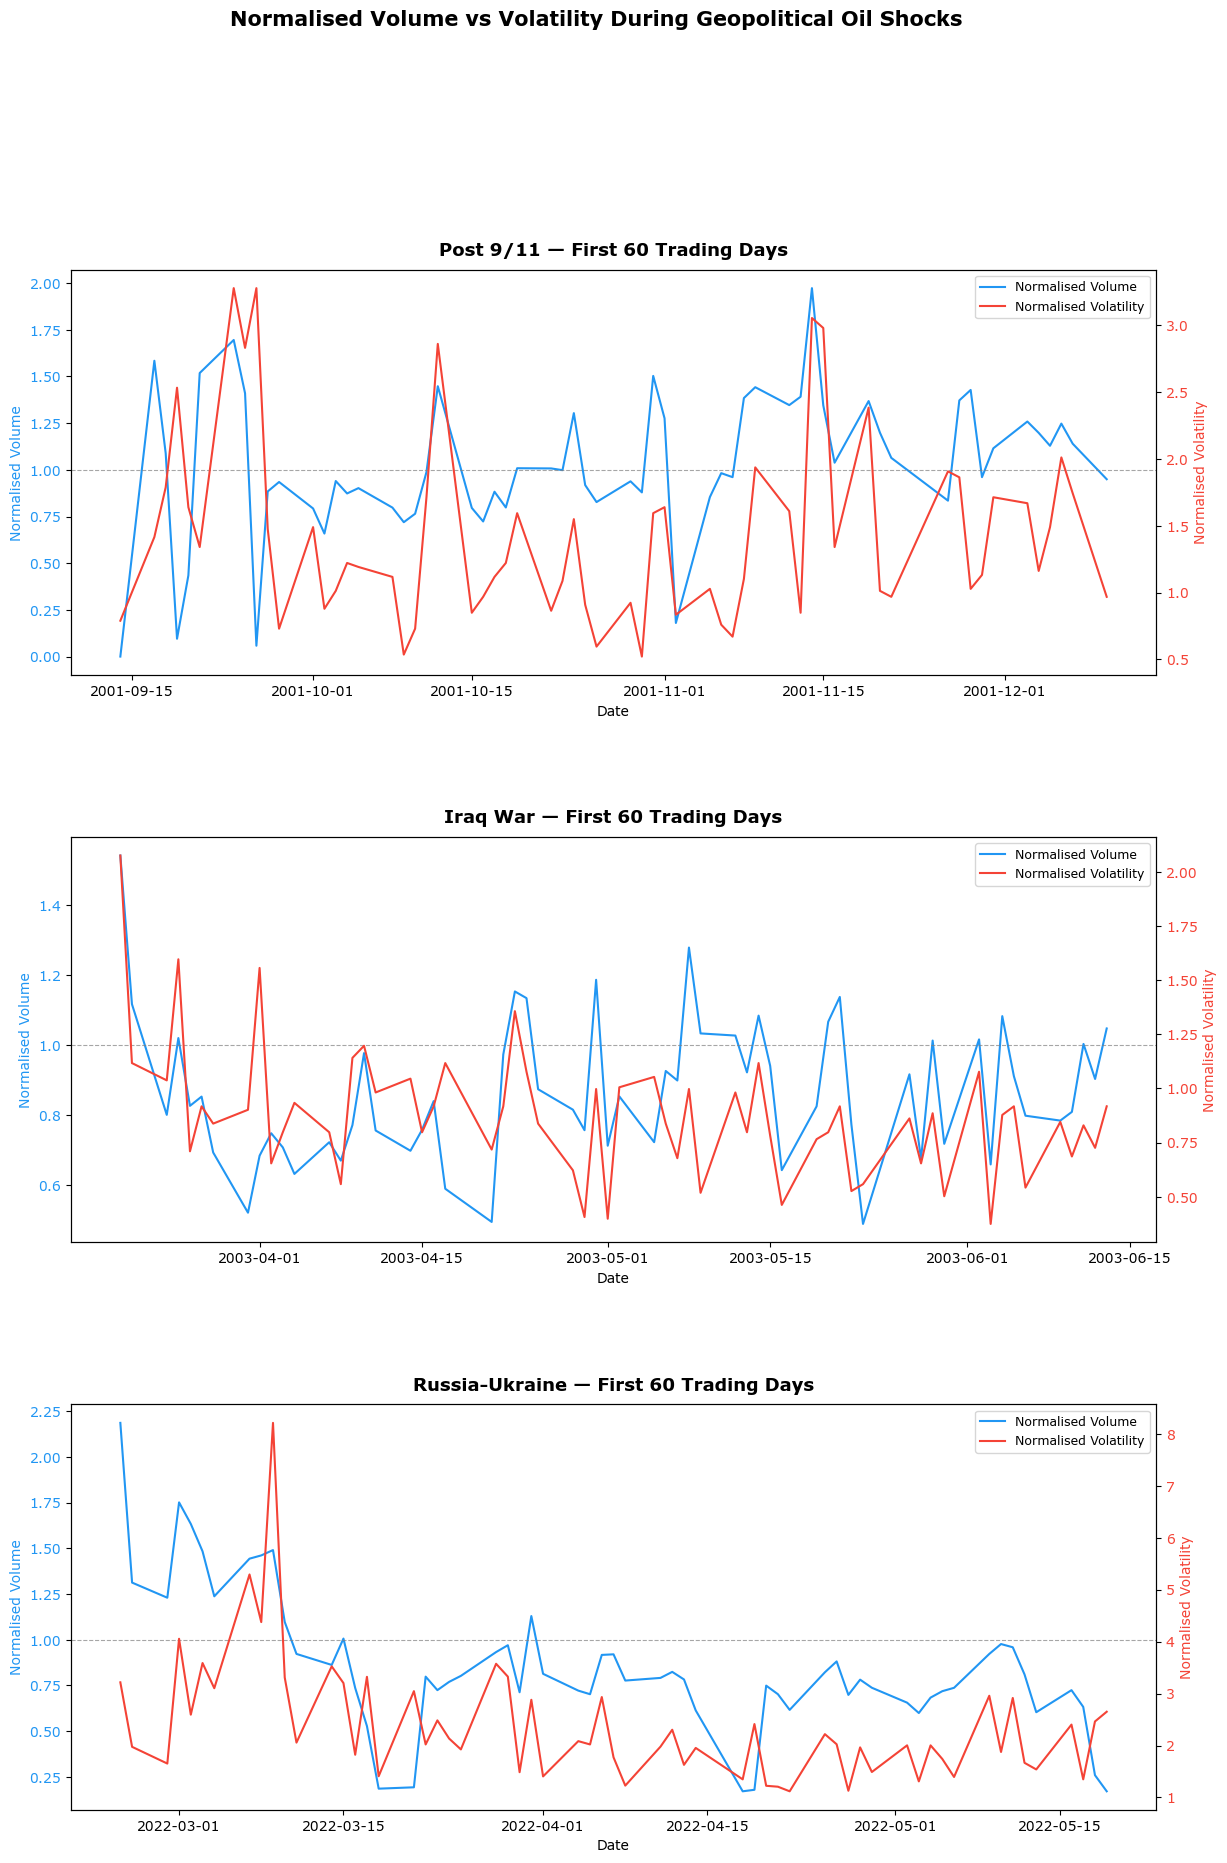

Plot 1 saved successfully


In [10]:
fig = plt.figure(figsize=(14, 20))
gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.4)

conflicts_to_plot = ['Post 9/11', 'Iraq War', 'Russia-Ukraine']
colors = {
    'Volume': '#2196F3',
    'Volatility': '#F44336'
}

for i, name in enumerate(conflicts_to_plot):
    ax1 = fig.add_subplot(gs[i])
    
    event_start = conflicts[name]['event_start']
    event_end = conflicts[name]['event_end']
    
    event_data = df.loc[event_start:event_end, 
                        [f'{name}_Volume_Norm', 
                         f'{name}_Volatility_Norm']].dropna().iloc[:60]
    
    ax2 = ax1.twinx()
    
    ax1.plot(event_data.index, 
             event_data[f'{name}_Volume_Norm'],
             color=colors['Volume'],
             linewidth=1.5,
             label='Normalised Volume')
    
    ax2.plot(event_data.index,
             event_data[f'{name}_Volatility_Norm'],
             color=colors['Volatility'],
             linewidth=1.5,
             label='Normalised Volatility')
    
    ax1.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    
    ax1.set_title(f'{name} — First 60 Trading Days',
                  fontsize=13, fontweight='bold', pad=10)
    ax1.set_xlabel('Date', fontsize=10)
    ax1.set_ylabel('Normalised Volume', color=colors['Volume'], fontsize=10)
    ax2.set_ylabel('Normalised Volatility', color=colors['Volatility'], fontsize=10)
    
    ax1.tick_params(axis='y', labelcolor=colors['Volume'])
    ax2.tick_params(axis='y', labelcolor=colors['Volatility'])
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, 
               loc='upper right', fontsize=9)

plt.suptitle('Normalised Volume vs Volatility During Geopolitical Oil Shocks',
             fontsize=15, fontweight='bold', y=1.01)

plt.savefig('event_period_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved successfully")


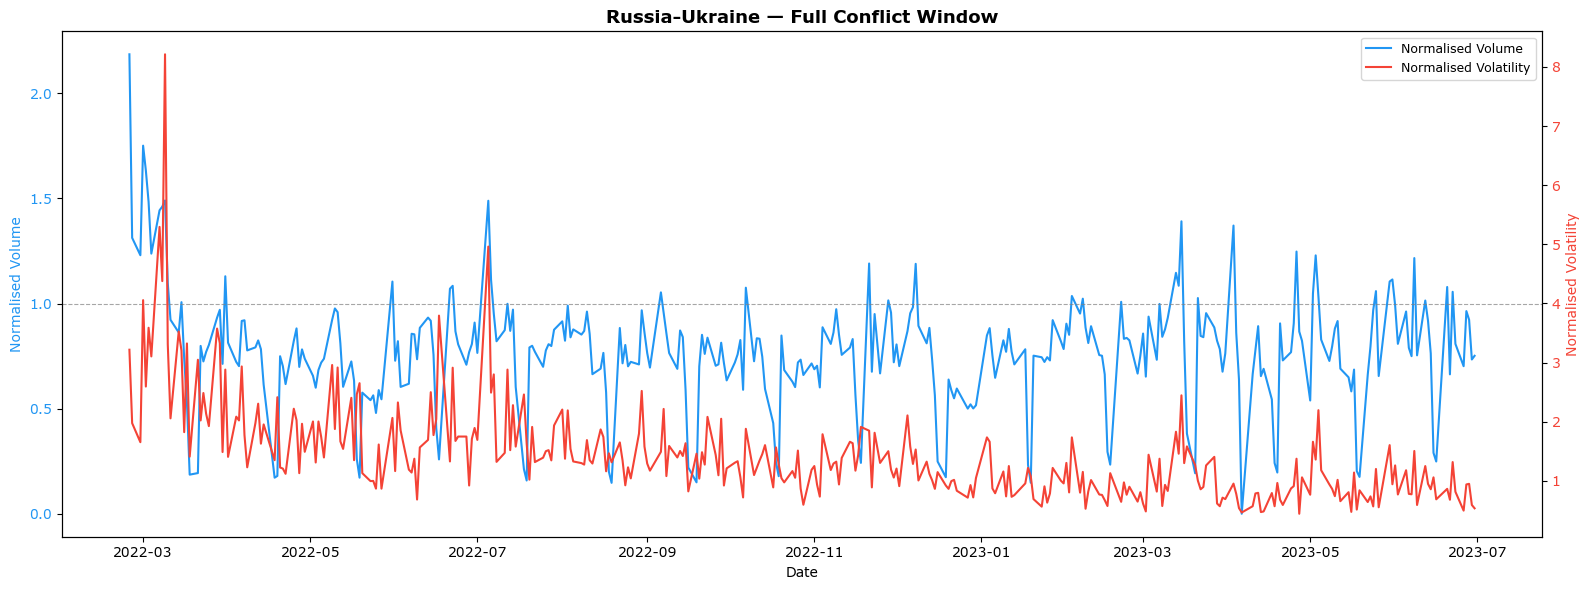

In [11]:
fig, ax1 = plt.subplots(figsize=(16, 6))

event_data_full = df.loc[conflicts['Russia-Ukraine']['event_start']:conflicts['Russia-Ukraine']['event_end'],
                         ['Russia-Ukraine_Volume_Norm', 
                          'Russia-Ukraine_Volatility_Norm']].dropna()

ax2 = ax1.twinx()

ax1.plot(event_data_full.index,
         event_data_full['Russia-Ukraine_Volume_Norm'],
         color=colors['Volume'],
         linewidth=1.5,
         label='Normalised Volume')

ax2.plot(event_data_full.index,
         event_data_full['Russia-Ukraine_Volatility_Norm'],
         color=colors['Volatility'],
         linewidth=1.5,
         label='Normalised Volatility')

ax1.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

ax1.set_title('Russia-Ukraine — Full Conflict Window', fontsize=13, fontweight='bold')
ax1.set_xlabel('Date', fontsize=10)
ax1.set_ylabel('Normalised Volume', color=colors['Volume'], fontsize=10)
ax2.set_ylabel('Normalised Volatility', color=colors['Volatility'], fontsize=10)

ax1.tick_params(axis='y', labelcolor=colors['Volume'])
ax2.tick_params(axis='y', labelcolor=colors['Volatility'])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('russia_ukraine_full.png', dpi=150, bbox_inches='tight')
plt.show()


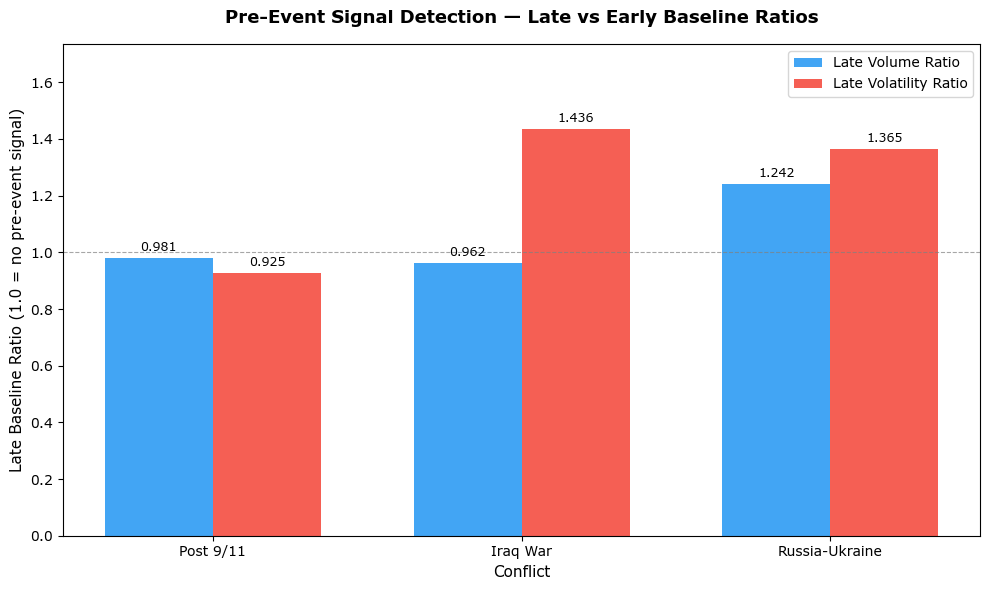

Plot 2 saved successfully


In [12]:
import numpy as np

conflicts_to_plot = ['Post 9/11', 'Iraq War', 'Russia-Ukraine']

volume_ratios = [pre_event_results[name]['Late Volume Ratio'] 
                 for name in conflicts_to_plot]
volatility_ratios = [pre_event_results[name]['Late Volatility Ratio'] 
                     for name in conflicts_to_plot]

x = np.arange(len(conflicts_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

volume_bars = ax.bar(x - width/2, volume_ratios, 
                     width, 
                     label='Late Volume Ratio',
                     color=colors['Volume'],
                     alpha=0.85)

volatility_bars = ax.bar(x + width/2, volatility_ratios,
                         width,
                         label='Late Volatility Ratio',
                         color=colors['Volatility'],
                         alpha=0.85)

ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

ax.bar_label(volume_bars, padding=3, fmt='%.3f', fontsize=9)
ax.bar_label(volatility_bars, padding=3, fmt='%.3f', fontsize=9)

ax.set_title('Pre-Event Signal Detection — Late vs Early Baseline Ratios',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Conflict', fontsize=11)
ax.set_ylabel('Late Baseline Ratio (1.0 = no pre-event signal)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(conflicts_to_plot, fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim(0, max(max(volume_ratios), max(volatility_ratios)) + 0.3)

plt.tight_layout()
plt.savefig('pre_event_signal.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved successfully")


## Plot 2 — Pre-Event Signal Detection

### What This Chart Shows
Each conflict has two bars — late volume ratio in blue and late volatility ratio in red. The dashed line at 1.0 represents no pre-event signal. Values above 1.0 indicate that metric was elevated in the final days before the event began relative to the early baseline, suggesting anticipatory positioning was already underway.

### Visual Interpretation
The chart makes three distinct market behaviour profiles immediately readable:

**Post 9/11** shows both bars below 1.0 — the only conflict where markets were quieter than normal immediately before the event. This is the natural control case confirming the framework's validity. No anticipation existed because no information was available.

**Iraq War** shows a striking asymmetry between the two bars — volume ratio near 1.0 while volatility ratio sits at 1.44. This visual gap captures the hedging-without-conviction dynamic precisely. The bars tell the story directly: traders were elevating volatility through options hedging while leaving directional volume completely unchanged.

**Russia-Ukraine** shows both bars elevated simultaneously and proportionally — a visually distinct profile from Iraq War. Volume and volatility rose together pre-event, reflecting the confident directional positioning enabled by weeks of publicly visible troop buildups.

### The Progression
Reading the chart left to right — from Post 9/11 through Iraq War to Russia-Ukraine — visually traces the spectrum of market anticipation. Suppressed signals, asymmetric hedging, and simultaneous confident positioning represent three distinct behavioural profiles that map directly onto the lead-lag findings in Step 3. The chart is not just a summary of pre-event data — it is a visual argument for the central conclusion of this analysis.


## Overall Conclusion

### Central Finding
This analysis investigated whether a consistent lead-lag relationship exists between intraday price volatility and trading volume during geopolitical oil shocks, and whether that relationship differs across conflicts with varying degrees of public anticipation.
The data does not support a single universal lead-lag pattern. Instead, three geopolitical conflicts spanning 25 years of oil market data reveal a spectrum determined by the degree of public information available before each shock:

**Full surprise (Post 9/11)** produced the strongest directional lead-lag structure. With no anticipatory positioning possible, markets processed the shock sequentially — volatility absorbed the initial impact first through immediate hedging, with directional volume following as traders developed frameworks for the shock's implications.

**Partial anticipation (Iraq War)** produced near-zero correlations in both directions. Partial public information enabled volatility hedging but not confident directional volume positioning pre-event, leaving markets caught between sequential and simultaneous processing during the conflict itself. Neither metric consistently preceded the other.

**Full anticipation (Russia-Ukraine)** produced simultaneous movement with weak aggregate correlations — but visualisation revealed this as a methodological artefact rather than absence of relationship. The shift(1) lag approach mechanically misaligns simultaneously peaking metrics, producing weak correlation numbers that mask genuine simultaneous co-movement. Full anticipation enabled complete pre-positioning, leaving no sequential signal to detect once the invasion began.

### Methodological Limitations

**Lead-lag measurement:** The shift(1) Pearson correlation approach assumes sequential relationships exist to detect. When markets process shocks simultaneously, this method produces misleading weak correlations that could be misread as absence of relationship. Future analysis should complement shift(1) correlations with visual inspection and phase-specific calculations to capture temporal evolution within event windows.

**Baseline window:** The 30-day pre-event baseline is assumed rather than optimised. A sensitivity analysis across multiple window sizes would strengthen the robustness of normalisation conclusions.

**Event end dates:** Conflict end dates involve judgment calls rather than systematic criteria such as price returning within 10% of pre-event baseline. Systematic end date definition would improve reproducibility.

**Sample size:** Three historical conflicts is insufficient to generalise the spectrum finding with statistical confidence. The pattern is compelling but must be treated as exploratory.

### Important Methodological Acknowledgment
The spectrum hypothesis — that degree of public anticipation determines lead-lag structure — emerged from interpreting results rather than being pre-specified before analysis. This is exploratory analysis rather than hypothesis testing, and the finding should be framed accordingly. 

A falsifiable prediction that would confirm this hypothesis against new data: 
a fourth conflict with moderate and partially public anticipation should produce moderate correlations — neither the directional asymmetry of Post 9/11 nor the simultaneous movement of Russia-Ukraine, but the near-zero random noise pattern observed in Iraq War. Testing this prediction against additional conflicts would determine whether the spectrum is a genuine market phenomenon or a pattern retrofitted to three data points.

### Implications
These findings challenge the assumption that volume reliably acts as a leading confirming indicator during geopolitical crises — a common premise in technical trading analysis. Whether volume leads, follows, or moves simultaneously with volatility appears to depend fundamentally on how much information markets had access to before the shock arrived. In an era of increasing geopolitical transparency through satellite imagery, open-source intelligence, and real-time news, the Iraq War and Russia-Ukraine findings suggest that future conflicts with visible buildups may increasingly produce simultaneous rather than sequential market reactions — progressively eroding the predictive value of volume as a leading indicator in geopolitical contexts.
